In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/CloudExify_Internship/Project1_SalesAnalysis')

In [ ]:
import pandas as pd
df = pd.read_csv('retail_store_sales.csv')
df.head(20)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


Exploring The Data

In [ ]:
# Checking size of dataset (no.of rows and columns)
print("Shape:", df.shape)

# Counting datatype and non null for evry column
print("\n--- Info ---")
df.info()

# Statistical summary for numeric columns (mean, std, min, max, etc.)
print("\n--- Describe ---")
df.describe()

Shape: (12575, 11)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB

--- Describe ---


,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [ ]:
#counting missing values in each column
print("Missing Values per coulmn: ")
print(df.isnull().sum())

#Missing values as percentage of total rows
print("\nMissing Values % ")
print((df.isnull().sum()/len(df))*100)


Missing Values per coulmn: 
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

Missing Values % 
Transaction ID       0.000000
Customer ID          0.000000
Category             0.000000
Item                 9.646123
Price Per Unit       4.842942
Quantity             4.803181
Total Spent          4.803181
Payment Method       0.000000
Location             0.000000
Transaction Date     0.000000
Discount Applied    33.391650
dtype: float64


In [ ]:
# Check for fully duplicated rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
# Check how many of the three related columns are missing per row
missing_count = df[['Price Per Unit', 'Quantity', 'Total Spent']].isnull().sum(axis=1)

# Distribution: 0 missing, 1 missing, 2 missing, 3 missing
print(missing_count.value_counts().sort_index())

0    11362
1      609
2      604
Name: count, dtype: int64


In [ ]:
# Handling missing values in Price Per Unit, Quantity, Total Spent
# Relationship: Total Spent = Price Per Unit x Quantity

# Creating a flag: True if exactly ONE of the three columns is missing in that row
mask_one_missing = df[['Price Per Unit', 'Quantity', 'Total Spent']].isnull().sum(axis=1) == 1

# Case 1: Total Spent is missing, but Price and Quantity are available
# Formula: Total Spent = Price Per Unit x Quantity
df.loc[mask_one_missing & df['Total Spent'].isnull(), 'Total Spent'] = (
    df['Price Per Unit'] * df['Quantity']
)

# Case 2: Price Per Unit is missing, but Total Spent and Quantity are available
# Formula: Price Per Unit = Total Spent / Quantity
df.loc[mask_one_missing & df['Price Per Unit'].isnull(), 'Price Per Unit'] = (
    df['Total Spent'] / df['Quantity']
)

# Case 3: Quantity is missing, but Total Spent and Price Per Unit are available
# Formula: Quantity = Total Spent / Price Per Unit
df.loc[mask_one_missing & df['Quantity'].isnull(), 'Quantity'] = (
    df['Total Spent'] / df['Price Per Unit']
)

# Create a flag: True if TWO or more of the three columns are missing
# These rows cannot be calculated (not enough information), so we drop them
mask_two_missing = df[['Price Per Unit', 'Quantity', 'Total Spent']].isnull().sum(axis=1) >= 2
df = df[~mask_two_missing]

# Verify: all three columns should now show 0 missing values
print("Missing values after fixing Price/Quantity/Total Spent:")
print(df[['Price Per Unit', 'Quantity', 'Total Spent']].isnull().sum())

Missing values after fixing Price/Quantity/Total Spent:
Price Per Unit    0
Quantity          0
Total Spent       0
dtype: int64


In [ ]:
# Handling missing values in Item column
# Item name cannot be calculated from other columns, so we label it clearly
# instead of dropping the whole row (other columns in that row are still useful)
df['Item'] = df['Item'].fillna('Unknown Item')

In [ ]:
for col in ['Price Per Unit', 'Quantity', 'Total Spent']:
    print(f"\n{col}:")
    print(df[col].unique())


Price Per Unit:
[18.5 29.  21.5 27.5 12.5 20.   5.  36.5  8.   6.5 39.5 23.  14.  35.
  9.5 24.5 33.5 41.  38.  15.5 11.  32.  26.  30.5 17. ]

Quantity:
[10.  9.  2.  7.  8.  1.  3.  6.  4.  5.]

Total Spent:
[185.  261.   43.  247.5  87.5 200.   40.   27.5 109.5  72.   52.   45.5
 237.   55.  232.  275.   23.  126.  105.   66.5  18.5  49.  134.  410.
 245.  182.5 100.  196.  315.  287.   76.   92.5 190.  255.5 276.5  46.5
   8.  107.5 165.   80.  192.5 335.   66.  215.   96.   42.   11.  234.
 316.   82.5 180.  365.   39.  172.  122.   30.   84.  320.  219.   67.
 146.  290.   70.  160.   82.   14.  355.5 124.   28.5  47.5 193.5  38.
  12.5 140.  120.  183.  305.   41.  155.   19.5  33.  108.5 119.  280.
  62.   32.  380.  304.  139.5 114.  192.  167.5  88.  395.  158.   25.
  50.   32.5  15.   33.5  24.  111.   46.   36.5  62.5 161.   26.   98.
  85.  228.   91.5  93.   35.  208.  100.5   9.5  10.  138.  288.   60.
 123.   73.  197.5  69.   61.  116.   55.5   6.5 152.5 118.5  74.  

In [ ]:
df['Item'].unique()

array(['Item_10_PAT', 'Item_17_MILK', 'Item_12_BUT', 'Item_16_BEV',
       'Item_6_FOOD', 'Unknown Item', 'Item_1_FOOD', 'Item_16_FUR',
       'Item_22_BUT', 'Item_3_BUT', 'Item_2_FOOD', 'Item_24_PAT',
       'Item_16_MILK', 'Item_17_PAT', 'Item_13_EHE', 'Item_7_BEV',
       'Item_4_EHE', 'Item_10_FOOD', 'Item_14_FUR', 'Item_20_BUT',
       'Item_25_FUR', 'Item_14_FOOD', 'Item_22_PAT', 'Item_11_FOOD',
       'Item_6_PAT', 'Item_21_EHE', 'Item_25_BEV', 'Item_23_FOOD',
       'Item_10_FUR', 'Item_11_BEV', 'Item_23_BUT', 'Item_22_BEV',
       'Item_10_EHE', 'Item_24_BUT', 'Item_8_BEV', 'Item_3_FOOD',
       'Item_12_FOOD', 'Item_16_CEA', 'Item_11_PAT', 'Item_16_BUT',
       'Item_5_CEA', 'Item_19_MILK', 'Item_23_FUR', 'Item_7_FUR',
       'Item_15_CEA', 'Item_6_MILK', 'Item_24_CEA', 'Item_22_CEA',
       'Item_22_FOOD', 'Item_2_BUT', 'Item_14_PAT', 'Item_12_PAT',
       'Item_18_FOOD', 'Item_1_PAT', 'Item_4_BEV', 'Item_22_FUR',
       'Item_7_PAT', 'Item_20_CEA', 'Item_20_FOOD', 'Item_11_

In [ ]:
#  Handling missing values in Discount Applied column
# Missing here means the discount status was never recorded (not the same as False)
# So we treat it as its own category instead of guessing True/False
df['Discount Applied'] = df['Discount Applied'].fillna('Unknown')

In [ ]:
df['Discount Applied'].unique()

array([True, False, 'Unknown'], dtype=object)

In [ ]:
df['Transaction Date'].unique()

array(['2024-04-08', '2023-07-23', '2022-10-05', ..., '2024-02-29',
       '2022-09-16', '2023-03-17'], dtype=object)

In [ ]:
# Converting Transaction Date to proper datetime format
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
print(df['Transaction Date'])

0       2024-04-08
1       2023-07-23
2       2022-10-05
3       2022-05-07
4       2022-10-02
           ...    
12570   2023-09-03
12571   2022-08-12
12572   2024-08-24
12573   2023-12-30
12574   2022-08-06
Name: Transaction Date, Length: 11971, dtype: datetime64[ns]


In [ ]:
# FINAL CHECK: confirm no missing values remain anywhere

print("Final missing values check:")
print(df.isnull().sum())

print("\nFinal dataset shape:", df.shape)

Final missing values check:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

Final dataset shape: (11971, 11)


Exploratory Data Analysis (EDA)

In [ ]:
# Applying basic descriptive statistics on cleaned dataset
print("Total Revenue Rs", df['Total Spent'].sum())
print("Avearage Transaction Value: Rs",df['Total Spent'].mean())
print("Median Average Transaction Value: Rs",df['Total Spent'].median())
print("Standard Deviation Rs", df['Total Spent'].std())

Total Revenue Rs 1552071.0
Avearage Transaction Value: Rs 129.6525770612313
Median Average Transaction Value: Rs 108.5
Standard Deviation Rs 94.75069674502333


In [ ]:
# Top selling categories by total revenue
top_categories = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)
print(top_categories)

Category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: Total Spent, dtype: float64


In [ ]:
# Top 10 selling items (excluding rows where item was unknown)
# Exclude 'Unknown Item' rows for this specific analysis since we don't know the real item name
known_items = df[df['Item'] != 'Unknown Item']

top_items = known_items.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(10)
print(top_items)

Item
Item_25_FUR     25256.0
Item_25_EHE     23083.0
Item_25_BUT     21894.0
Item_24_FUR     21172.0
Item_25_FOOD    20541.0
Item_22_BUT     19710.0
Item_23_BUT     19114.0
Item_20_BUT     18860.5
Item_19_MILK    18848.0
Item_23_EHE     18468.0
Name: Total Spent, dtype: float64


VISUALIZATION

In [ ]:
# STEP: Monthly sales trend
# Group revenue by month (using the Transaction Date column)
monthly_sales = df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Spent'].sum()
print("Monthly Sales:")
print(monthly_sales)

# Identify the best performing month
best_month = monthly_sales.idxmax()
print("\nBest Month:", best_month, "with Revenue: Rs", monthly_sales.max())

Monthly Sales:
Transaction Date
2022-01    52911.5
2022-02    43325.5
2022-03    40996.0
2022-04    40442.0
2022-05    40347.5
2022-06    42576.0
2022-07    44471.5
2022-08    41333.5
2022-09    46113.5
2022-10    38355.0
2022-11    41256.5
2022-12    38201.0
2023-01    48052.5
2023-02    39214.5
2023-03    38534.5
2023-04    38905.5
2023-05    40480.5
2023-06    42474.0
2023-07    45632.5
2023-08    38592.0
2023-09    41069.0
2023-10    38322.0
2023-11    37014.0
2023-12    43021.0
2024-01    47908.5
2024-02    37145.0
2024-03    42861.5
2024-04    46271.0
2024-05    43766.5
2024-06    44721.0
2024-07    41405.0
2024-08    43362.0
2024-09    42161.5
2024-10    42736.5
2024-11    44076.0
2024-12    48466.5
2025-01    25548.5
Freq: M, Name: Total Spent, dtype: float64

Best Month: 2022-01 with Revenue: Rs 52911.5


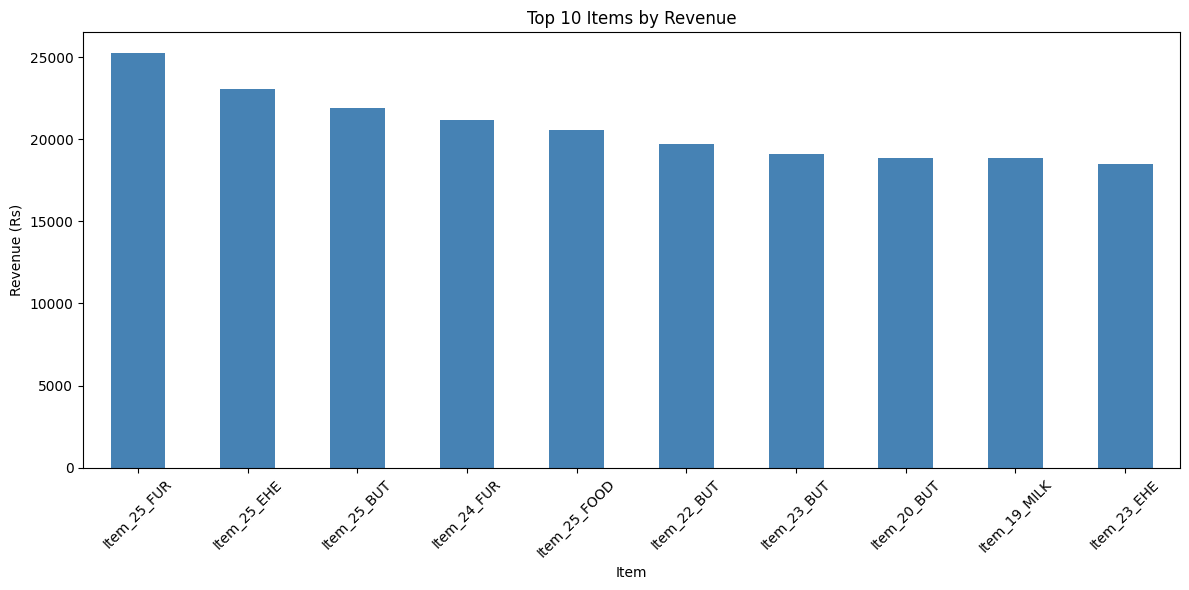

In [ ]:
import matplotlib.pyplot as plt
# Top 10 items by revenue (bar chart)

top_items.plot(kind='bar', figsize=(12, 6), color='steelblue')
plt.title('Top 10 Items by Revenue')
plt.xlabel('Item')
plt.ylabel('Revenue (Rs)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

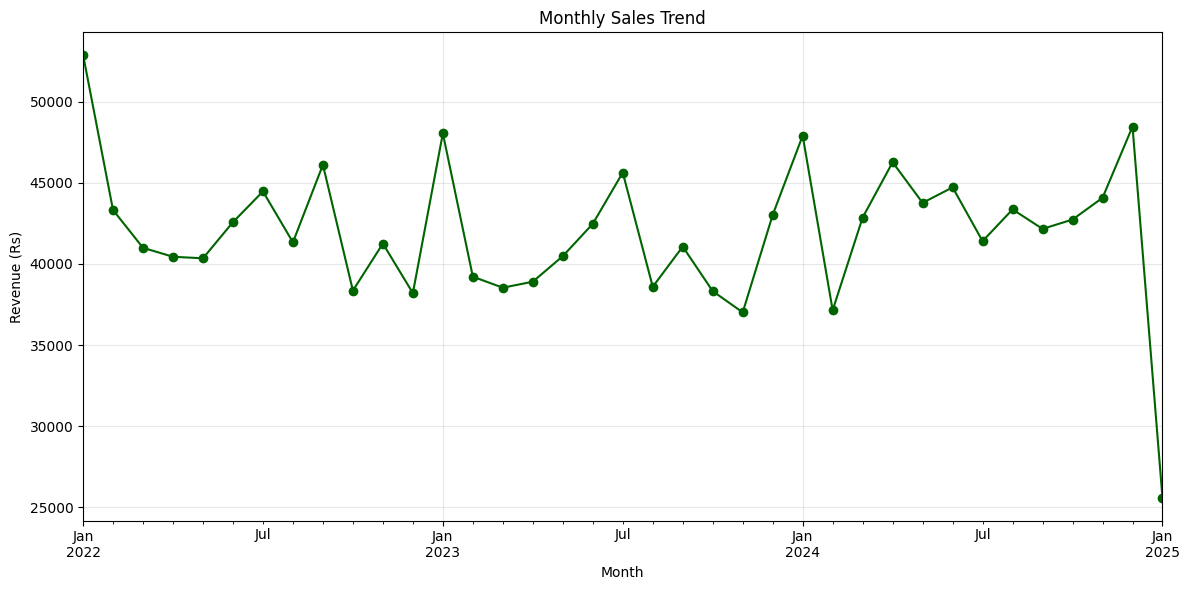

In [ ]:
# Monthly sales trend (line plot)

monthly_sales.plot(kind='line', figsize=(12, 6), marker='o', color='darkgreen')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

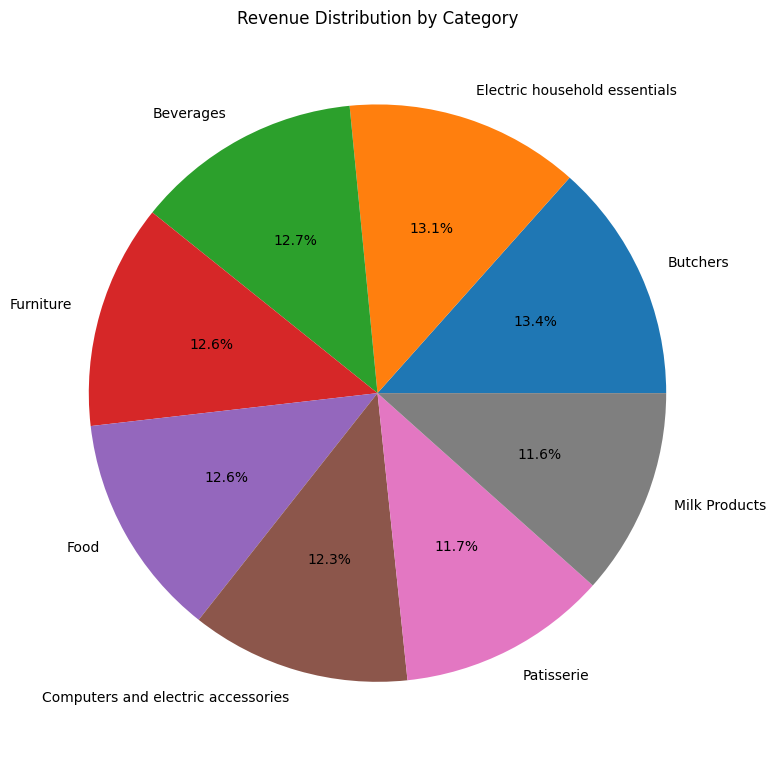

In [ ]:
# Revenue distribution by Category (pie chart)

top_categories.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Revenue Distribution by Category')
plt.ylabel('')  # removed default y-label for cleaner look
plt.tight_layout()
plt.show()

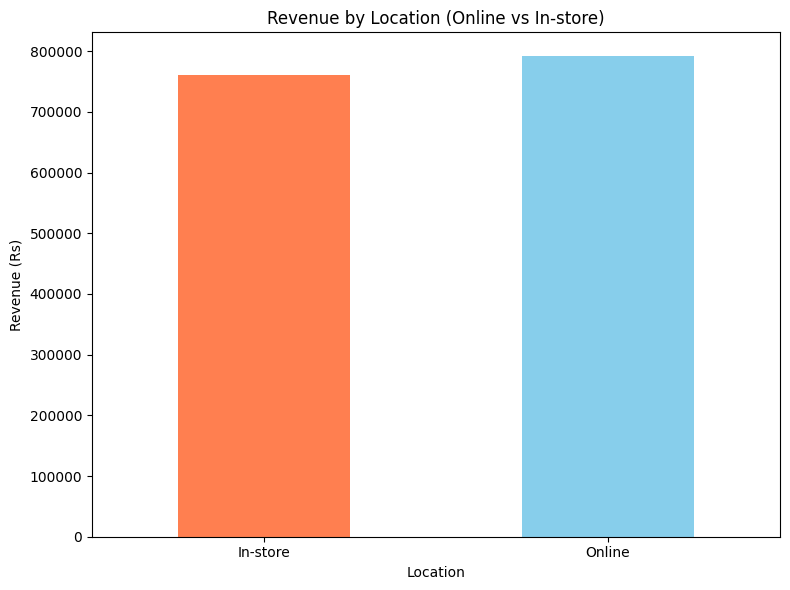

In [ ]:
# Revenue by Location (Online vs In-store) —
# using Location instead of Region since this dataset has no geographic region

by_location = df.groupby('Location')['Total Spent'].sum()
by_location.plot(kind='bar', figsize=(8, 6), color=['coral', 'skyblue'])
plt.title('Revenue by Location (Online vs In-store)')
plt.xlabel('Location')
plt.ylabel('Revenue (Rs)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# summary report to a text file

report_text = f"""{"=" * 50}
SALES ANALYSIS REPORT
{"=" * 50}

Total Records Analyzed: {len(df)}
Date Range: {df['Transaction Date'].min().date()} to {df['Transaction Date'].max().date()}
Total Revenue: Rs {df['Total Spent'].sum():,.0f}
Average Transaction Value: Rs {df['Total Spent'].mean():,.0f}
Median Transaction Value: Rs {df['Total Spent'].median():,.0f}

Top 5 Categories by Revenue:
{top_categories.head(5).to_string()}

Top 5 Items by Revenue:
{top_items.head(5).to_string()}

Best Performing Month: {best_month}
Revenue in Best Month: Rs {monthly_sales.max():,.0f}

Revenue Split — Online vs In-store:
{by_location.to_string()}

Data Quality Notes:
- Original dataset had {12575 - 11971} rows removed due to multiple missing critical values
- Missing Item names labeled as 'Unknown Item' ({609} rows, later filled)
- Missing Discount status labeled as 'Unknown' ({3988} rows)
{"=" * 50}
"""

with open('report.txt', 'w') as f:
    f.write(report_text)

print("Report saved as report.txt")
print(report_text)

Report saved as report.txt
SALES ANALYSIS REPORT

Total Records Analyzed: 11971
Date Range: 2022-01-01 to 2025-01-18
Total Revenue: Rs 1,552,071
Average Transaction Value: Rs 130
Median Transaction Value: Rs 108

Top 5 Categories by Revenue:
Category
Butchers                         208118.0
Electric household essentials    203813.5
Beverages                        197047.5
Furniture                        195310.0
Food                             194812.0

Top 5 Items by Revenue:
Item
Item_25_FUR     25256.0
Item_25_EHE     23083.0
Item_25_BUT     21894.0
Item_24_FUR     21172.0
Item_25_FOOD    20541.0

Best Performing Month: 2022-01
Revenue in Best Month: Rs 52,912

Revenue Split — Online vs In-store:
Location
In-store    760670.0
Online      791401.0

Data Quality Notes:
- Original dataset had 604 rows removed due to multiple missing critical values
- Missing Item names labeled as 'Unknown Item' (609 rows, later filled)
- Missing Discount status labeled as 'Unknown' (3988 rows)



In [28]:
import os
print("Current folder:", os.getcwd())

Current folder: /content/drive/MyDrive/CloudExify_Internship/Project1_SalesAnalysis
